# State based analysis after HMM-GLM fit

In [2]:
import sys
import os
import pickle
import ssm
import pandas as pd
from scipy.stats import sem
from itertools import combinations
from scipy.stats import ttest_rel
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.anova import AnovaRM

# Make sure we're adding the root of Project_monkey
project_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))  # Two levels up from notebooks
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Now this should work
#from Behaviour.scripts_beh import preprocessing_hmm_glm
from Behaviour.scripts_beh.preprocessing_hmm_glm import *
from Behaviour.scripts_beh.fit_hmm_glm_and_predictive_states_extraction import *
from Behaviour.scripts_beh.three_state_bootsrap import *

figures_dir = os.path.join(project_root, "Behaviour", "Figures")
os.makedirs(figures_dir, exist_ok=True)

### This state based analysis uses stored summary files from the HMM-GLM fit and bootstrap. It can be adapted to any number of states

In [3]:
# paramters of the model
num_states = 3 # Number of states in the HMM-GLM
obs_dim = 1 # Dimension of the observation (e.g., 1 for binary choice)
num_iters = 1500 # Number of iterations for fitting the model
tolerance = 1e-4 # Tolerance for convergence, standard value
observations = "input_driven_obs" # Type of observations, can be modified
transitions = "standard" # Type of transitions, can be modified

In [4]:
# From the data select the regressors we would like to include in the inpts, can be modified accordingly
# This will determine the dimension of the inputs

feature_names = [
            'color', 'direction', 'p_color', 'dist_prev_current_color',
            'p_direction', 'dist_prev_current_motion', 'prev_response', 'intercept'
        ]

In [5]:
# Load and prepare the inputs for the HMM-GLM model
data_path = os.path.join("..", "..", "Data", "sample_data.pkl")
inpts, choices, data = load_and_prepare_glmhmm_inputs(data_path, feature_names)


In [6]:
# Initialization of the model for the reconstruction of the HMM-GLM
model = define_glmhmm_model(inpts, num_states =3)

In [8]:
# Loadin the model parameters from the stored files

summary = load_bootstrap_summary("glm_bootstrap_summary.pkl")

recovered_weights = summary["glm_weights"]        # shape: [num_states, 1, input_dim]
recovered_trans_mat =summary["transition_matrix"] # shape: [num_states, num_states]



#### computing the posterioir probabilities after loading the saved parameters

In [9]:
# Set the model to the recovered parameters
model.observations.params = recovered_weights
model.transitions.log_Ps = recovered_trans_mat

# Compute posterior state probabilities
posterior_probs = [
    model.expected_states(data=y, input=X)[0]
    for y, X in zip(choices, inpts)
]


In [10]:
# This function stores and load the predictive states and assigns it a column in data
data = assign_predictive_3_states(
    data=data,
    posterior_probs = posterior_probs,
    weight_matrix = summary["glm_weights"],  # shape: (3, 1, input_dim)
    filename="predictive_3_states.pkl"
)

[INFO] State identity → color: 1, motion: 0, default: 2
[INFO] Predictive states saved to the folder results.
[INFO] 'predictiveStates' assigned to all sessions.


### 2D psychometric curves


=== State 0 ===
P(choose Left) by Color (rows) × Direction (columns):
direction_bin         0         1
color_bin                        
1              0.071970  0.866873
0              0.005051  0.957929

=== State 1 ===
P(choose Left) by Color (rows) × Direction (columns):
direction_bin         0         1
color_bin                        
1              0.895397  0.639024
0              0.010101  0.025000

=== State 2 ===
P(choose Left) by Color (rows) × Direction (columns):
direction_bin         0         1
color_bin                        
1              0.630631  0.757812
0              0.000000  0.340659


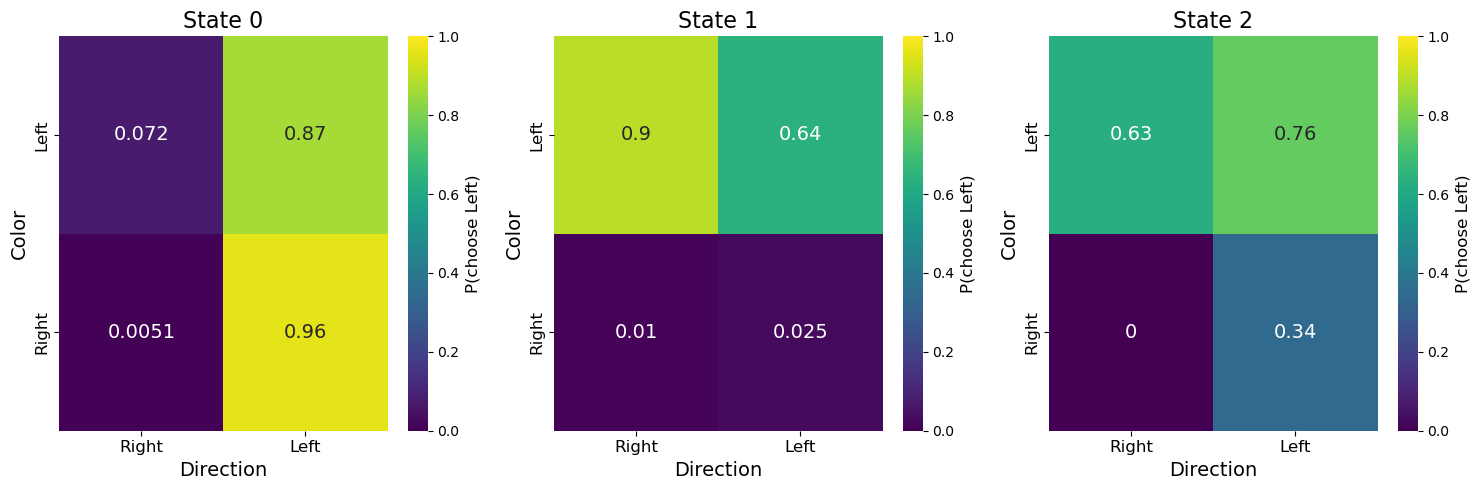

In [15]:
all_data_df = pd.concat(data, ignore_index=True)

# Step 2: Binarize stimulus values
all_data_df['color_bin'] = (all_data_df['color'] >= 0).astype(int)       # 1 = left, 0 = right
all_data_df['direction_bin'] = (all_data_df['direction'] >= 0).astype(int)

# Step 3: Identify all unique predictive states
unique_states = sorted(all_data_df['predictiveStates'].dropna().unique().astype(int))
num_states = len(unique_states)

# Determine grid shape for plotting
ncols = min(num_states, 4)
nrows = int(np.ceil(num_states / ncols))

# Step 4: Create figure
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 5 * nrows))
axes = np.atleast_2d(axes).flatten()

for i, state in enumerate(unique_states):
    df_state = all_data_df[all_data_df['predictiveStates'] == state]

    # Compute mean choice per color_bin × direction_bin
    grouped = df_state.groupby(['color_bin', 'direction_bin'])['chosenResponse'].mean().reset_index()
    heatmap_data = grouped.pivot(index='color_bin', columns='direction_bin', values='chosenResponse')
    heatmap_data = heatmap_data.sort_index(ascending=False)

    print(f"\n=== State {state} ===")
    print("P(choose Left) by Color (rows) × Direction (columns):")
    print(heatmap_data)

    ax = axes[i]
    sns.heatmap(
        heatmap_data,
        annot=True,
        annot_kws={"fontsize": 14},
        cmap='viridis',
        vmin=0, vmax=1,
        xticklabels=['Right', 'Left'],
        yticklabels=['Left', 'Right'],
        cbar_kws={'label': 'P(choose Left)'},
        ax=ax
    )
    ax.set_title(f"State {state}", fontsize=16)
    ax.set_xlabel("Direction", fontsize=14)
    ax.set_ylabel("Color", fontsize=14)
    ax.tick_params(axis='both', labelsize=12)
    ax.figure.axes[-1].yaxis.label.set_size(12)

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()

# Save the figure
fig_path = os.path.join(figures_dir, "heatmap_p_choose_left_by_state.svg")
fig.savefig(fig_path, format='svg', bbox_inches='tight')
            
plt.show()

###  Context composition per predictive state

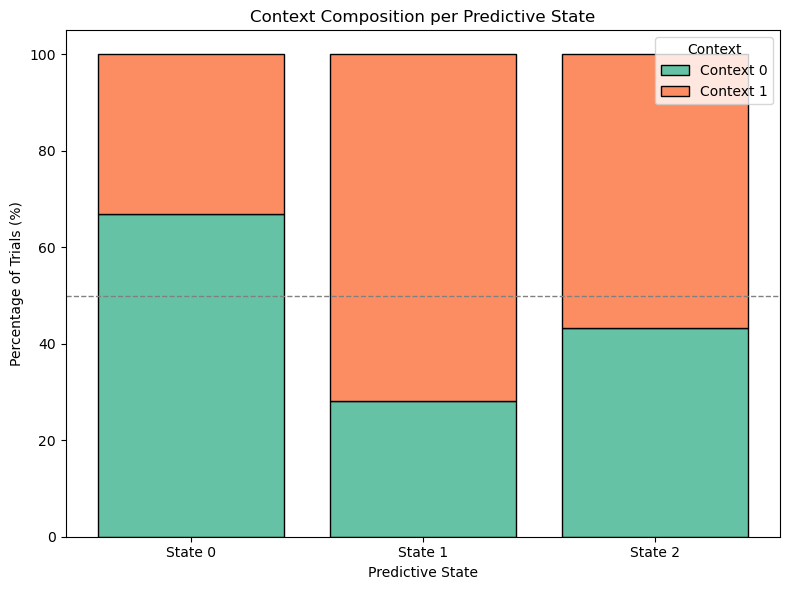

In [16]:
# Aggregate context counts per predictive state
counts = []

for df in data:
    if not {'predictiveStates', 'rule'}.issubset(df.columns):
        continue

    df_clean = df.dropna(subset=['predictiveStates', 'rule'])
    grouped = df_clean.groupby(['predictiveStates', 'rule']).size().reset_index(name='count')
    counts.append(grouped)

# Continue only if valid data was found
if counts:
    count_df = pd.concat(counts, ignore_index=True)
    pivot = count_df.pivot_table(
        index='predictiveStates', columns='rule', values='count',
        aggfunc='sum', fill_value=0
    )

    percent = pivot.div(pivot.sum(axis=1), axis=0) * 100
    if 0 in percent.columns and 1 in percent.columns:
        percent = percent[[0, 1]]

    # Plot
    colors = ['#66c2a5', '#fc8d62']  # Context 0 and 1
    fig, ax = plt.subplots(figsize=(8, 6))
    bottom = np.zeros(len(percent))
    for i, ctx in enumerate(percent.columns):
        ax.bar(
            percent.index,
            percent[ctx],
            bottom=bottom,
            label=f"Context {ctx}",
            color=colors[i % len(colors)],
            edgecolor='k'
        )
        bottom += percent[ctx].values

    ax.axhline(50, color='gray', linestyle='--', linewidth=1)
    ax.set_xticks(percent.index)
    ax.set_xticklabels([f"State {int(s)}" for s in percent.index])
    ax.set_ylabel('Percentage of Trials (%)')
    ax.set_xlabel('Predictive State')
    ax.set_title('Context Composition per Predictive State')
    ax.legend(title='Context')
    plt.tight_layout()

    # === Save the figure ===
    fig_path = os.path.join(figures_dir, "context_composition_per_predictive_state.svg")
    fig.savefig(fig_path, format='svg', bbox_inches='tight')
    
    plt.show()
else:
    print("[INFO] No valid dataframes with 'predictiveStates' and 'rule' found.")



###  Accuracy per predictive state

Accuracy comparison: State 0 vs State 1 — p = 0.0722 → n.s.
Accuracy comparison: State 0 vs State 2 — p = 0.0369 → *
Accuracy comparison: State 1 vs State 2 — p = 0.0277 → *


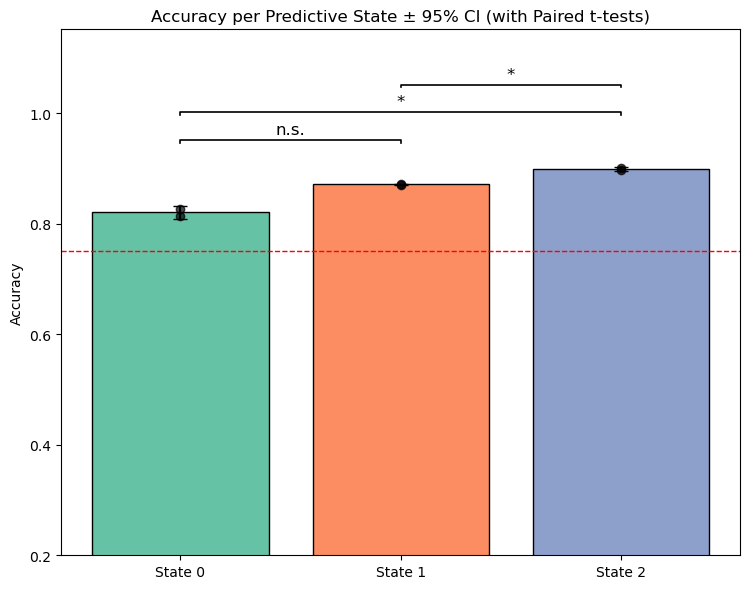

In [23]:
acc_records = []

for sess_idx, df in enumerate(data):
    required_cols = {'predictiveStates', 'expectedResponse', 'chosenResponse'}
    if not required_cols.issubset(df.columns):
        continue

    df = df.dropna(subset=required_cols).copy()
    df['correct_response'] = (df['chosenResponse'] == df['expectedResponse']).astype(int)

    grouped = df.groupby('predictiveStates')['correct_response'].mean()
    for state, acc in grouped.items():
        acc_records.append({'session': sess_idx, 'state': int(state), 'accuracy': acc})

# Convert to DataFrame
acc_df = pd.DataFrame(acc_records)

# Create labels and colors
unique_states = sorted(acc_df['state'].unique())
label_map = {s: f"State {s}" for s in unique_states}
color_palette = sns.color_palette("Set2", len(unique_states))
state_colors = {label_map[s]: color_palette[i] for i, s in enumerate(unique_states)}

acc_df['state_label'] = acc_df['state'].map(label_map)

# Pivot to sessions × states
pivot_acc = acc_df.pivot(index='session', columns='state_label', values='accuracy')
pivot_acc = pivot_acc[[label_map[s] for s in unique_states]]  # Ensure order

# Compute means and confidence intervals
mean_acc = pivot_acc.mean()
ci_acc = sem(pivot_acc, nan_policy='omit') * 1.96

# Plotting
x_labels = mean_acc.index.tolist()
x = np.arange(len(x_labels))

fig, ax = plt.subplots(figsize=(1.2 * len(x_labels) + 4, 6))
bar_colors = [state_colors[label] for label in x_labels]

ax.bar(x, mean_acc.values, yerr=ci_acc, capsize=5, color=bar_colors, edgecolor='k', zorder=1)

# Dot overlay
for i, label in enumerate(x_labels):
    y_vals = pivot_acc[label].dropna().values
    x_vals = np.full_like(y_vals, x[i], dtype=float)
    ax.scatter(x_vals, y_vals, color='black', alpha=0.7, zorder=2)

# Paired t-tests
ymax = (mean_acc + ci_acc).max()
h = 0.05
offset = 0
for s1, s2 in combinations(x_labels, 2):
    common = pivot_acc[[s1, s2]].dropna()
    if not common.empty:
        stat, pval = ttest_rel(common[s1], common[s2])
        x1, x2 = x[x_labels.index(s1)], x[x_labels.index(s2)]
        y = ymax + h * (offset + 1)
        ax.plot([x1, x1, x2, x2], [y - 0.005, y, y, y - 0.005], color='k', lw=1.2)
        label = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'n.s.'
        ax.text((x1 + x2) / 2, y + 0.005, label, ha='center', va='bottom', fontsize=12)
        print(f"Accuracy comparison: {s1} vs {s2} — p = {pval:.4f} → {label}")
        offset += 1

ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_ylim(0.2, ymax + h * (offset + 2))
ax.axhline(0.75, color='red', linestyle='--', linewidth=1)
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy per Predictive State ± 95% CI (with Paired t-tests)')
plt.tight_layout()

# === Save the figure ===
fig_path = os.path.join(figures_dir, "accuracy_per_state_with_ttests.svg")
fig.savefig(fig_path, format='svg', bbox_inches='tight')

plt.show()


###  Plotting probabilities of states by stimulus

Plot P(state = k) vs stimulus strength, separately for color and motion contexts

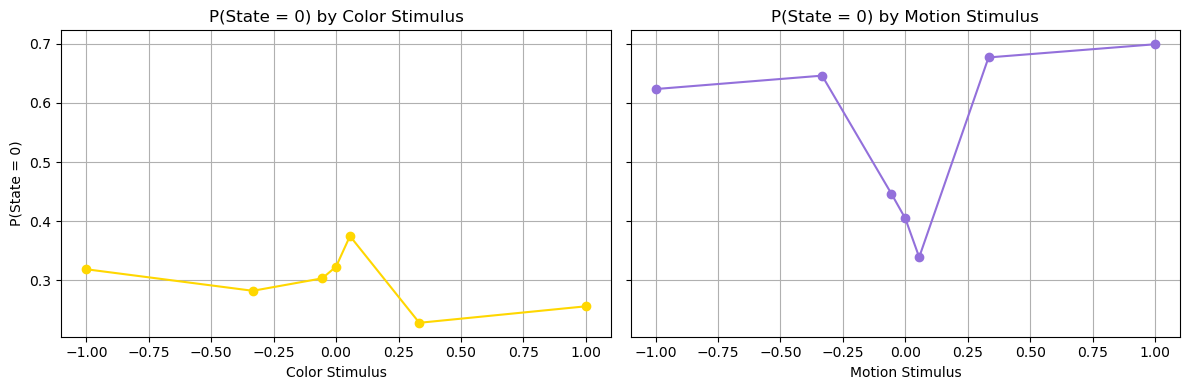

In [25]:
# Choose the state you want to visualize
state_to_plot = 0  # <-- Change this to 1 or 2, etc., if needed

color_stim = []
color_states = []

motion_stim = []
motion_states = []

# Aggregate stimulus and state info
for df in data:
    if all(col in df.columns for col in ['rule', 'direction', 'color', 'predictiveStates']):
        df = df.copy()

        is_color = df['rule'] == 1
        is_motion = df['rule'] == 0

        color_stim.extend(df.loc[is_color, 'color'].values)
        color_states.extend(df.loc[is_color, 'predictiveStates'].values)

        motion_stim.extend(df.loc[is_motion, 'direction'].values)
        motion_states.extend(df.loc[is_motion, 'predictiveStates'].values)

# Create DataFrames
color_df = pd.DataFrame({'stim': color_stim, 'state': color_states})
motion_df = pd.DataFrame({'stim': motion_stim, 'state': motion_states})

# Add match column and compute probabilities
color_df['match'] = color_df['state'] == state_to_plot
motion_df['match'] = motion_df['state'] == state_to_plot

color_prop = color_df.groupby('stim')['match'].mean().sort_index()
motion_prop = motion_df.groupby('stim')['match'].mean().sort_index()

# Plot
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axs[0].plot(color_prop.index, color_prop.values, marker='o', color='gold')
axs[0].set_title(f"P(State = {state_to_plot}) by Color Stimulus")
axs[0].set_xlabel("Color Stimulus")
axs[0].set_ylabel(f"P(State = {state_to_plot})")
axs[0].grid(True)

axs[1].plot(motion_prop.index, motion_prop.values, marker='o', color='mediumpurple')
axs[1].set_title(f"P(State = {state_to_plot}) by Motion Stimulus")
axs[1].set_xlabel("Motion Stimulus")
axs[1].grid(True)

# Save figure
fig_path = os.path.join(figures_dir, "state_stimulus_composition.svg")
fig.savefig(fig_path, format='svg', bbox_inches='tight')

plt.tight_layout()
plt.show()



###  Analyze reaction time by state



Repeated Measures ANOVA:
              Anova
      F Value Num DF Den DF Pr > F
----------------------------------
state  5.7057 2.0000 2.0000 0.1491


ANOVA not significant — no post-hoc tests run.


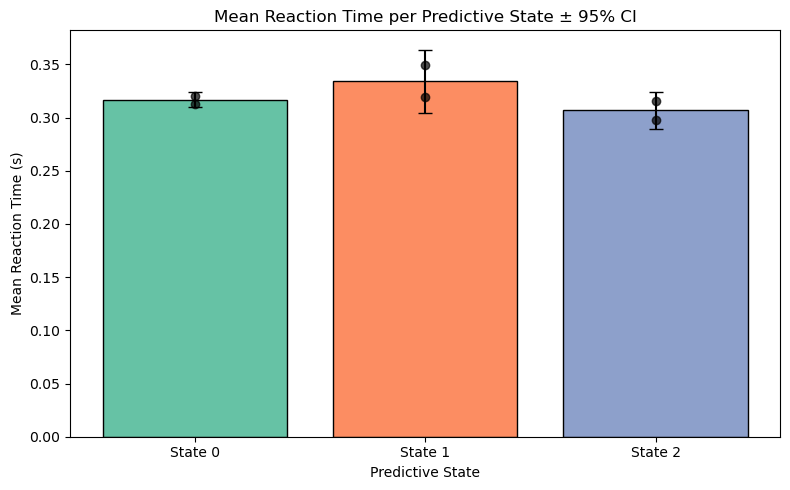

In [28]:
rt_session_data = []

for sess_idx, df in enumerate(data):
    if 'reactionTime' not in df.columns or 'predictiveStates' not in df.columns:
        continue

    filtered_df = df.dropna(subset=['reactionTime', 'predictiveStates'])
    if filtered_df.empty:
        continue

    grouped = filtered_df.groupby('predictiveStates')['reactionTime'].mean()

    for state, mean_rt in grouped.items():
        rt_session_data.append({
            'session': sess_idx,
            'state': int(state),
            'mean_rt': mean_rt
        })

# Create dataframe
rt_df = pd.DataFrame(rt_session_data)
if rt_df.empty:
    print("No valid reaction time data available.")

# Pivot and filter
pivot_rt = rt_df.pivot(index='session', columns='state', values='mean_rt')
pivot_rt = pivot_rt.dropna(axis=1, how='all').sort_index(axis=1)
balanced_rt_df = pivot_rt.dropna(axis=0)

if balanced_rt_df.shape[0] < 2:
    print("Not enough complete sessions for statistical analysis.")


# Compute summary stats
mean_rt = balanced_rt_df.mean()
ci_rt = sem(balanced_rt_df, nan_policy='omit') * 1.96
x_pos = np.arange(len(mean_rt))
state_labels = [f"State {int(s)}" for s in mean_rt.index]

# Assign colors
palette = sns.color_palette("Set2", len(mean_rt))
bar_colors = palette[:len(mean_rt)]

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x_pos, mean_rt.values, yerr=ci_rt, capsize=5,
       color=bar_colors, edgecolor='k', zorder=1)

# Dot overlay
for i, state in enumerate(mean_rt.index):
    y_vals = balanced_rt_df[state].dropna().values
    x_vals = np.full_like(y_vals, x_pos[i], dtype=float)
    ax.scatter(x_vals, y_vals, color='black', alpha=0.7, zorder=2)

# ANOVA
melted_rt = balanced_rt_df.reset_index().melt(id_vars='session', var_name='state', value_name='rt')
melted_rt['state'] = melted_rt['state'].astype(str)

aovrm = AnovaRM(melted_rt, 'rt', 'session', within=['state'])
result = aovrm.fit()
print("\nRepeated Measures ANOVA:")
print(result)

pval_anova = result.anova_table['Pr > F'].iloc[0]

# Post-hoc if significant
if pval_anova < 0.05:
    print("\nANOVA significant — running post-hoc tests...")
    comparisons = list(combinations(balanced_rt_df.columns, 2))
    raw_pvals = []

    for s1, s2 in comparisons:
        stat, pval = ttest_rel(balanced_rt_df[s1], balanced_rt_df[s2], nan_policy='omit')
        raw_pvals.append(pval)

    reject, corrected_pvals, _, _ = multipletests(raw_pvals, method='bonferroni')

    ymax = (mean_rt + ci_rt).max()
    h = 0.05

    for i, ((s1, s2), pval, sig) in enumerate(zip(comparisons, corrected_pvals, reject)):
        i1, i2 = list(mean_rt.index).index(s1), list(mean_rt.index).index(s2)
        x1, x2 = x_pos[i1], x_pos[i2]
        y = ymax + h * (i + 1)
        ax.plot([x1, x1, x2, x2], [y - 0.005, y, y, y - 0.005], color='k', lw=1.2)

        label = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'n.s.'
        ax.text((x1 + x2) / 2, y + 0.005, label, ha='center', va='bottom', fontsize=12)
        print(f"Post-hoc: State {s1} vs State {s2} — p = {pval:.4f} → {label}")
else:
    print("\nANOVA not significant — no post-hoc tests run.")

# Final formatting
ax.set_xticks(x_pos)
ax.set_xticklabels(state_labels)
ax.set_ylabel('Mean Reaction Time (s)')
ax.set_xlabel('Predictive State')
ax.set_title('Mean Reaction Time per Predictive State ± 95% CI')
plt.tight_layout()

# === Save the figure ===
fig_path = os.path.join(figures_dir, "mean_reaction_time_per_predictive_state.svg")
fig.savefig(fig_path, format='svg', bbox_inches='tight')

plt.show()

###  Psychometric curves by previous response and state

Plot P(choose Left) psychometric curves by previous response for each predictive state.

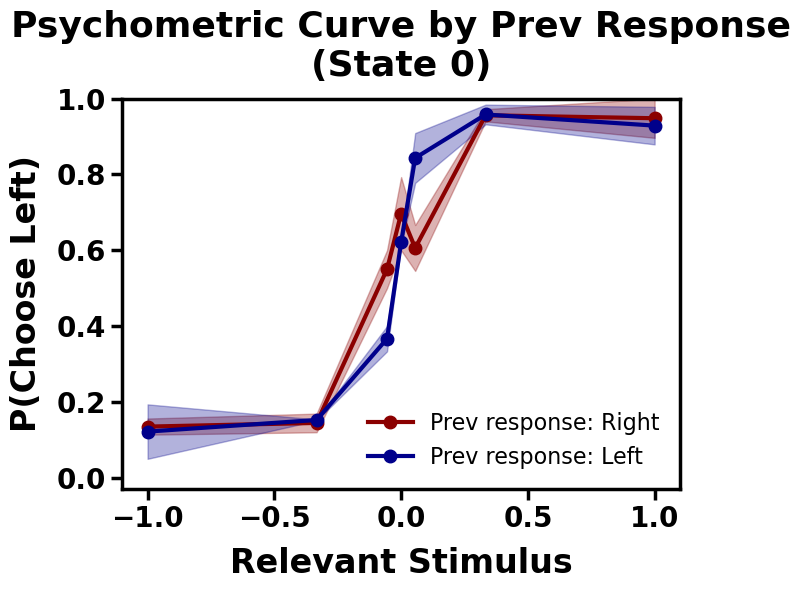

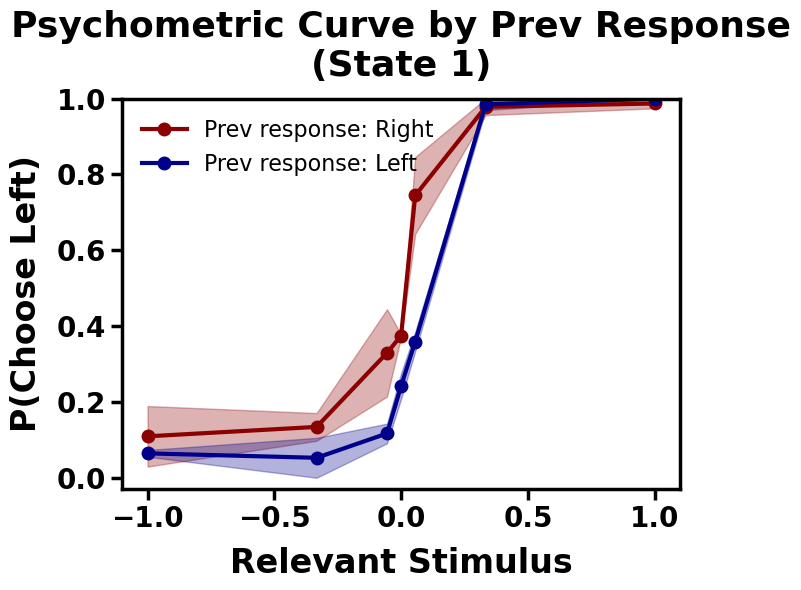

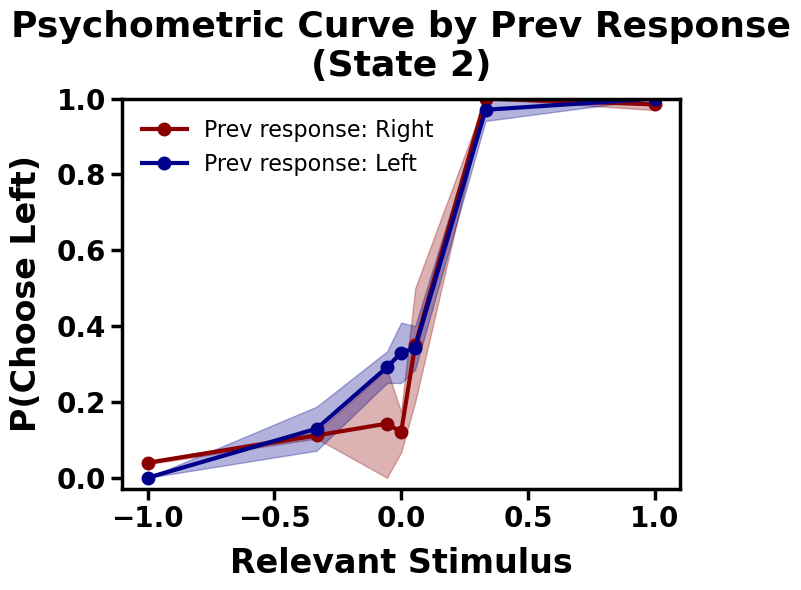

In [29]:
# Collect all unique stimulus values
unique_relevant_stim = sorted(set().union(*[
    set(df.loc[df['context'] == 1, 'color'].round(6).dropna().unique())
    .union(set(df.loc[df['context'] == 0, 'direction'].round(6).dropna().unique()))
    for df in data if {'context', 'color', 'direction'}.issubset(df.columns)
]))

all_states = np.unique(np.concatenate([
    df['predictiveStates'].dropna().values for df in data if 'predictiveStates' in df.columns
])).astype(int)

for state in all_states:
    session_curves = []

    for df in data:
        if not {'predictiveStates', 'context', 'prev_response', 'chosenResponse', 'color', 'direction'}.issubset(df.columns):
            continue

        df = df.copy()
        df = df[df['predictiveStates'] == state]
        if df.empty:
            continue

        df['color'] = df['color'].round(6)
        df['direction'] = df['direction'].round(6)
        df['relevant_stim'] = df.apply(
            lambda row: row['color'] if row['context'] == 1 else row['direction'], axis=1
        )

        curves = {0: [], 1: []}
        for prev_resp in [0, 1]:
            subset = df[df['prev_response'] == prev_resp]
            probs = []
            for val in unique_relevant_stim:
                stim_data = subset[subset['relevant_stim'] == val]
                prob = stim_data['chosenResponse'].mean() if not stim_data.empty else np.nan
                probs.append(prob)
            curves[prev_resp] = probs

        session_curves.append(pd.DataFrame(curves, index=unique_relevant_stim))

    if not session_curves:
        continue

    # Stack and compute mean and CI
    stacked = np.stack([df.values for df in session_curves], axis=0)
    mean_curve = np.nanmean(stacked, axis=0)
    sem_curve = np.nanstd(stacked, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(stacked), axis=0))
    ci95 = sem_curve

    # Plot
    fig, ax = plt.subplots(figsize=(7, 6))
    colors = ['darkred', 'darkblue']
    labels = ['Prev response: Right', 'Prev response: Left']

    for i in range(2):
        ax.plot(unique_relevant_stim, mean_curve[:, i], marker='o',
                linewidth=3, markersize=9, label=labels[i], color=colors[i])
        ax.fill_between(unique_relevant_stim,
                        mean_curve[:, i] - ci95[:, i],
                        mean_curve[:, i] + ci95[:, i],
                        alpha=0.3, color=colors[i])

    ax.set_xlabel('Relevant Stimulus', fontsize=24, fontweight='bold', labelpad=10)
    ax.set_ylabel('P(Choose Left)', fontsize=24, fontweight='bold', labelpad=10)
    ax.set_title(f'Psychometric Curve by Prev Response\n(State {int(state)})',
                 fontsize=26, fontweight='bold', pad=16)

    ax.tick_params(axis='both', which='major', labelsize=20, length=8, width=2.5)
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')
    ax.set_ylim(-0.03, 1)
    ax.legend(fontsize=16, frameon=False, loc='best')

    plt.tight_layout()

    # === Save the figure ===
    fig_path = os.path.join(figures_dir, f"psychometric_prev_response_state_{int(state)}.svg")
    fig.savefig(fig_path, format='svg', bbox_inches='tight')
    
    plt.show()